In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram
from sklearn.metrics import silhouette_score, silhouette_samples

In [32]:
def data():
    data=pd.read_csv("spotify_songs.csv", index_col=1)
    data.drop(["track_id", "track_album_id", "playlist_id", "playlist_name", "playlist_subgenre"], inplace=True, axis=1)
    data.drop_duplicates(inplace=True)
    data.dropna(inplace=True)
    # Normalize year-only release dates like '2012' to '2012-01-01'
    data['track_album_release_date'] = data['track_album_release_date'].astype(str).str.strip()
    mask = data['track_album_release_date'].str.match(r'^\d{4}$')
    data.loc[mask, 'track_album_release_date'] = data.loc[mask, 'track_album_release_date'] + '-01-01'
    # Now parse all dates using YYYY-MM-DD format
    data['track_album_release_date']=pd.to_datetime(data['track_album_release_date'], format='mixed')
    return data

In [33]:
data=data()

In [34]:
data.columns

Index(['track_artist', 'track_popularity', 'track_album_name',
       'track_album_release_date', 'playlist_genre', 'danceability', 'energy',
       'key', 'loudness', 'mode', 'speechiness', 'acousticness',
       'instrumentalness', 'liveness', 'valence', 'tempo', 'duration_ms'],
      dtype='object')

In [12]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 30375 entries, I Don't Care (with Justin Bieber) - Loud Luxury Remix to Typhoon - Original Mix
Data columns (total 17 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   track_artist              30375 non-null  object        
 1   track_popularity          30375 non-null  int64         
 2   track_album_name          30375 non-null  object        
 3   track_album_release_date  30375 non-null  datetime64[ns]
 4   playlist_genre            30375 non-null  object        
 5   danceability              30375 non-null  float64       
 6   energy                    30375 non-null  float64       
 7   key                       30375 non-null  int64         
 8   loudness                  30375 non-null  float64       
 9   mode                      30375 non-null  int64         
 10  speechiness               30375 non-null  float64       
 11  acousticness    

In [13]:
features = ['danceability', 'energy', 'loudness', 'speechiness', 
            'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', "duration_ms"]

In [14]:
scaler=StandardScaler()
X=data[features]
X_scaled=scaler.fit_transform(X)

In [15]:
def plot_dendrogram(model, **kwargs):
    '''
    Create linkage matrix and then plot the dendrogram
    Arguments: 
    - model(HierarchicalClustering Model): hierarchical clustering model.
    - **kwargs
    Returns:
    None, but dendrogram plot is produced.
    '''
    # create the counts of samples under each node
    counts = np.zeros(model.children_.shape[0])
    n_samples = len(model.labels_)
    for i, merge in enumerate(model.children_):
        current_count = 0
        for child_idx in merge:
            if child_idx < n_samples:
                current_count += 1  # leaf node
            else:
                current_count += counts[child_idx - n_samples]
        counts[i] = current_count

    linkage_matrix = np.column_stack(
        [model.children_, model.distances_, counts]
    ).astype(float)

    # Plot the corresponding dendrogram
    dendrogram(linkage_matrix, **kwargs)

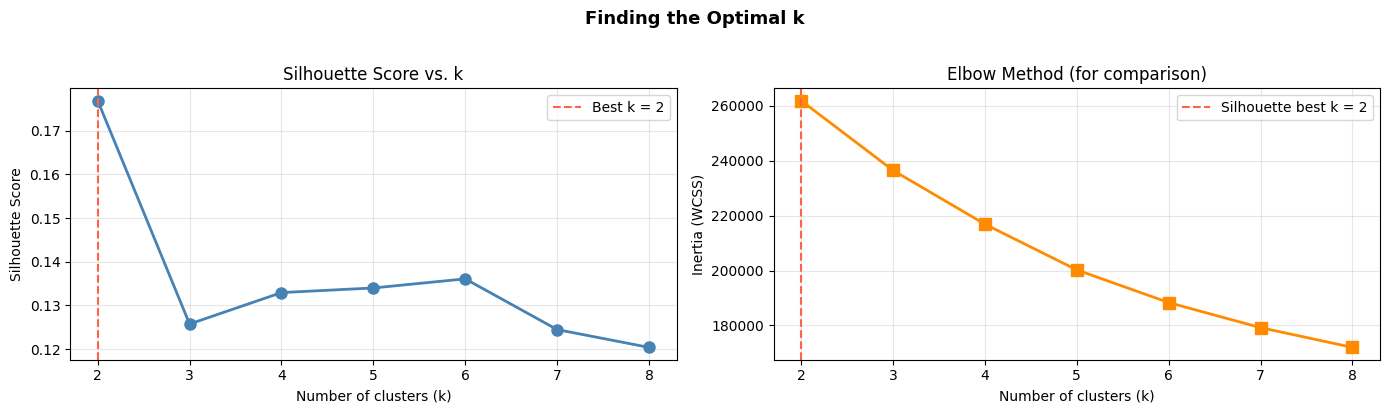


✅ Silhouette Score selects k = 2  (true clusters = 4)
  k=2  →  0.1769 ← best
  k=3  →  0.1257
  k=4  →  0.1329
  k=5  →  0.1340
  k=6  →  0.1361
  k=7  →  0.1245
  k=8  →  0.1204


In [ ]:
k_range = range(2, 9)
scores = []
inertias = []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=7, n_init=10)
    labels = km.fit_predict(X_scaled)
    scores.append(silhouette_score(X_scaled, labels))
    inertias.append(km.inertia_)

best_k = list(k_range)[np.argmax(scores)]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

# Silhouette curve
ax1.plot(list(k_range), scores, 'o-', color='steelblue', linewidth=2, markersize=8)
ax1.axvline(best_k, color='tomato', linestyle='--', label=f'Best k = {best_k}')
ax1.set_xlabel('Number of clusters (k)')
ax1.set_ylabel('Silhouette Score')
ax1.set_title('Silhouette Score vs. k')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Elbow curve for comparison
ax2.plot(list(k_range), inertias, 's-', color='darkorange', linewidth=2, markersize=8)
ax2.axvline(best_k, color='tomato', linestyle='--', label=f'Silhouette best k = {best_k}')
ax2.set_xlabel('Number of clusters (k)')
ax2.set_ylabel('Inertia (WCSS)')
ax2.set_title('Elbow Method (for comparison)')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.suptitle('Finding the Optimal k', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f"\n✅ Silhouette Score selects k = {best_k}  (true clusters = 4)")
for k, s in zip(k_range, scores):
    marker = " ← best" if k == best_k else ""
    print(f"  k={k}  →  {s:.4f}{marker}")

In [16]:
clustering = (
    AgglomerativeClustering(distance_threshold=0, n_clusters=None)
    .fit(X_scaled)
)

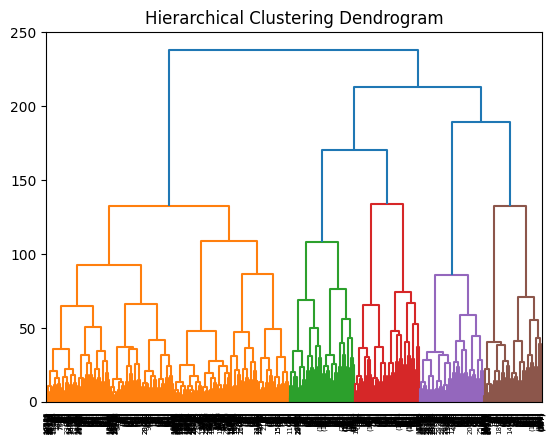

In [17]:
fig, ax = plt.subplots()
plt.title("Hierarchical Clustering Dendrogram")
plot_dendrogram(clustering, truncate_mode="level", p=10)
plt.show()